# Atividade 2: A Descoberta dos Padrões de Engajamento

### **Introdução:**

O objetivo desta atividade era claro, mas desafiador: utilizar aprendizado não supervisionado para entender os padrões por trás do engajamento em redes sociais. A meta não era simplesmente criar clusters, mas interpretá-los para responder à pergunta: **"O que realmente diferencia um post de sucesso de um que é ignorado?"**

Minha solução começou com a hipótese de que o tema do conteúdo seria o fator principal. No entanto, como este relatório irá demonstrar, a resposta era muito mais complexa e interessante. A seguir, documento o processo iterativo de análise, as hipóteses testadas, as descobertas que me levaram a mudar de estratégia e o desenvolvimento do modelo final.

In [ ]:
# instalações
!pip install -q pandas sentence-transformers scikit-learn matplotlib seaborn umap-learn torch transformers accelerate bitsandbytes


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 47.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 47.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 14.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 9.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 47.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.9/72.9 MB 9.2 MB/s eta 0:00:00


In [1]:
# importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sentence_transformers import SentenceTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import umap.umap_ as umap
from transformers import pipeline
import torch
import json
from sklearn.model_selection import KFold
import joblib
from sklearn.metrics import normalized_mutual_info_score
from sklearn.preprocessing import StandardScaler

### 1. Metodologia Inicial e Preparação dos Dados

O primeiro passo para agrupar as postagens por similaridade foi transformar o conteúdo textual de cada uma em um vetor numérico, ou *embedding*. Para esta tarefa, utilizei o modelo `all-MiniLM-L6-v2` da biblioteca `SentenceTransformer`, que oferece um excelente balanço entre velocidade e qualidade (eu tentei rodar o `all-mpnet-base-v2`, mas em 40 minutos nem 20% dos dados havia sido transformado).

In [43]:
# baixa e carrega o dataset de treino
!gdown -q 1csTzz_UWpe89KYh11qj_V7fDssTv2FFO
dados_treino = pd.read_csv('df_social_data_train.csv')

# limpa linhas com 'content' nulo
dados_treino.dropna(subset=['content'], inplace=True)
dados_treino['content'] = dados_treino['content'].astype(str)
print("dados carregados e limpos.")

# gera os embeddings para o dataset
print("gerando embeddings...")
modelo_st = SentenceTransformer("all-MiniLM-L6-v2")
dados_treino['features'] = list(modelo_st.encode(dados_treino['content'].tolist(), show_progress_bar=True))
print("embeddings ok.")


dados carregados e limpos.
gerando embeddings...


Batches:   0%|          | 0/704 [00:00<?, ?it/s]

embeddings ok.


In [ ]:
dados_treino # visualizar os dados só para eu ver se estava tudo certo

,anon_id,content,reactions,comments,score,engagement,features
0,afb338bc4e80e811be481b27807934c5,Robert Lerman writes that achieving a healthy...,12,1,13,low,"[-0.011695284, 0.02785928, 0.036047444, -0.030..."
1,afb338bc4e80e811be481b27807934c5,"National disability advocate Sara Hart Weir, ...",11,0,11,low,"[-0.02623733, -0.06488712, -0.007863777, 0.097..."
3,afb338bc4e80e811be481b27807934c5,Exploring in this months Talent Management & H...,44,0,44,low,"[-0.023109002, -0.020342559, 0.035548184, -0.0..."
4,afb338bc4e80e811be481b27807934c5,I count myself fortunate to have spent time wi...,22,2,24,low,"[-0.054384463, 0.0031936867, -0.06155944, 0.01..."
5,afb338bc4e80e811be481b27807934c5,Online job platforms are a different way of wo...,21,1,22,low,"[-0.068378225, -0.062780656, -0.010365994, -0...."
...,...,...,...,...,...,...,...
23803,ecc9ab53ac5a897358b35118221ea367,Check out my interview with @AaronBerson ! I w...,5,0,5,low,"[-0.074029945, 0.008327099, 0.005020871, 0.041..."
23804,ecc9ab53ac5a897358b35118221ea367,Check out my interview with @MikeMax32CPA abou...,3,0,3,low,"[-0.039110135, 0.0067848046, -0.011407465, 0.0..."
23805,ecc9ab53ac5a897358b35118221ea367,Love! #radicalcpa,76,3,79,low,"[-0.06677414, -0.011888947, 0.0026476763, -0.0..."
23806,ecc9ab53ac5a897358b35118221ea367,Did you know next year is going to be the best...,1,0,1,low,"[-0.07542417, 0.017530885, 0.023634885, -0.043..."


### 2. Determinando o Número Ideal de Clusters (k)

Com os embeddings gerados para todo o dataset, o próximo desafio era determinar o número ideal de clusters (`k`) a serem criados. Uma análise preliminar, rodando o `Silhouette Score` no dataset completo, se mostrou computacionalmente inviável. Portanto, adotei a metodologia robusta demonstrada em aula:

1.  Uma **amostra aleatória de 5.000 posts** foi criada para agilizar os cálculos.
2.  A dimensionalidade desta amostra foi reduzida de 384 para 5 dimensões usando **UMAP**, uma técnica que preserva a estrutura de vizinhança dos dados.
3.  O `Silhouette Score` foi então calculado nesta amostra reduzida para diferentes valores de `k`, permitindo uma estimativa eficiente e confiável do número de clusters.

criando amostra...
reduzindo dimensionalidade...


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


dimensionalidade ok.
calculando silhouette score...
k=2, score=0.2930
k=3, score=0.2718
k=4, score=0.3229
k=5, score=0.3285
k=6, score=0.3585
k=7, score=0.3593
k=8, score=0.3667
k=9, score=0.3669
k=10, score=0.3754
k=11, score=0.3764
k=12, score=0.3893
k=13, score=0.3580
k=14, score=0.3779
k=15, score=0.3904
k=16, score=0.3999
k=17, score=0.3897
k=18, score=0.3921
k=19, score=0.3855
k=20, score=0.3804

O melhor valor de k é: 16


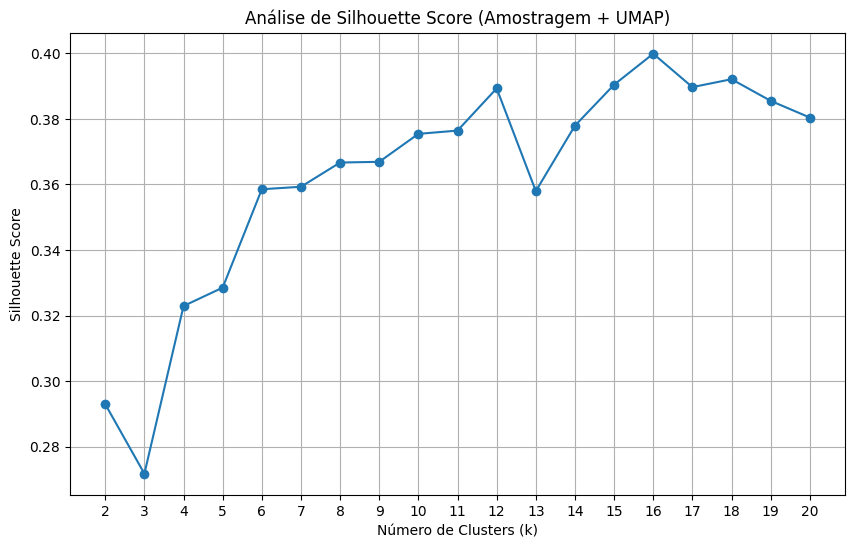

In [3]:
# criando uma amostra de 5000 posts para estimar o 'k'
print("criando amostra...")
dados_amostra = dados_treino.sample(n=10000, random_state=42)
features_amostra = np.array(dados_amostra['features'].tolist())

# reduz a dimensionalidade da amostra com umap
print("reduzindo dimensionalidade...")
reducer_umap = umap.UMAP(n_components=5,metric= 'cosine', random_state=42)
features_amostra_reduzida = reducer_umap.fit_transform(features_amostra)
print("dimensionalidade ok.")

# calcula o silhouette score para diferentes valores de k
intervalo_k = range(2, 21)
lista_silhouette = []

print("calculando silhouette score...")
for k in intervalo_k:
    modelo_kmeans_amostra = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo_kmeans_amostra.fit_predict(features_amostra_reduzida)
    score = silhouette_score(features_amostra_reduzida, labels)
    lista_silhouette.append(score)
    print(f"k={k}, score={score:.4f}")

best_k = intervalo_k[np.argmax(lista_silhouette)]
print(f"\nO melhor valor de k é: {best_k}")

# plota o gráfico para visualizar o melhor k
plt.figure(figsize=(10, 6))
plt.plot(intervalo_k, lista_silhouette, marker='o')
plt.title('Análise de Silhouette Score (Amostragem + UMAP)')
plt.xlabel('Número de Clusters (k)')
plt.ylabel('Silhouette Score')
plt.xticks(intervalo_k)
plt.grid(True)
plt.show()

### 3. Resultado da Análise de Silhueta e Clusterização

A análise de silhueta, facilitada pela redução de dimensionalidade com UMAP, revelou que o valor de `k=16` (importante avisar, esse valor muda dependendo do dispositivo, mesmo mantendo a mesma seed, quando rodei direto na minha máquina os resultados foram MUITO diferentes, não somente o k, mas os clusters que encontrei no meu computador pareciam separar muito melhor `high` e `low`, porém isso me mostrou que eu precisava tomar uma análise muito mais generalista, e não me prender aos clusters excelentes que eu havia encontrado) era o que proporcionava a melhor separação estrutural para a amostra de dados. Embora o score máximo não tenha sido drasticamente superior aos outros, ele serviu como um ponto de partida sólido e baseado em dados para a clusterização.

Com este valor definido, apliquei o algoritmo K-Means com `k=16` ao **dataset completo**, garantindo que cada uma das mais de 23 mil postagens fosse atribuída a um dos 16 "tópicos" encontrados. A tabela resultante mostra a distribuição de posts de alto e baixo engajamento em cada cluster, permitindo uma primeira análise quantitativa dos temas de maior sucesso.

In [44]:
# define o k com base na análise anterior
k_final = best_k

# pega as features de todos os dados de treino
todas_as_features = np.array(dados_treino['features'].tolist())

print(f"aplicando k-means com k={k_final}...")
modelo_kmeans_final = KMeans(n_clusters=k_final, random_state=42, n_init=10)
dados_treino['cluster'] = modelo_kmeans_final.fit_predict(todas_as_features)
print("clusterização ok.")

# analisa a distribuição de engajamento por cluster
print("\nanálise de engajamento por cluster:")
analise_clusters = pd.crosstab(dados_treino['cluster'], dados_treino['engagement'])
analise_clusters['proporcao_high'] = (analise_clusters['high'] / (analise_clusters['high'] + analise_clusters['low'])).round(3)

analise_clusters_ordenada = analise_clusters.sort_values(by='proporcao_high', ascending=False)
display(analise_clusters_ordenada)

aplicando k-means com k=16...
clusterização ok.

análise de engajamento por cluster:


engagement,high,low,proporcao_high
cluster,,,
4,758,1204,0.386
8,561,1220,0.315
15,470,1097,0.300
0,389,973,0.286
3,376,1188,0.240
11,299,960,0.237
6,242,862,0.219
13,342,1395,0.197
5,219,942,0.189


### 4. Visualização Supervisionada dos Clusters

Com os 16 clusters definidos e analisados quantitativamente, o próximo passo é tentar visualizá-los. O desafio é que os nossos dados existem em um espaço de 384 dimensões, impossível de ser plotado diretamente.

Para resolver isso, utilizei a mesma técnica do professor: o **UMAP Supervisionado**. Diferente de uma redução de dimensionalidade padrão, esta abordagem usa os rótulos de cluster que acabamos de criar como um "guia". Ela projeta os dados em um espaço 2D, mas com o objetivo explícito de manter os pontos do mesmo cluster próximos e os de clusters diferentes, separados. O resultado é um gráfico visualmente claro que, embora seja uma simplificação, nos ajuda a entender a estrutura que o K-Means encontrou.

gerando projeção 2d para visualização...


/usr/local/lib/python3.11/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


projeção 2d ok.
plotando visualização...


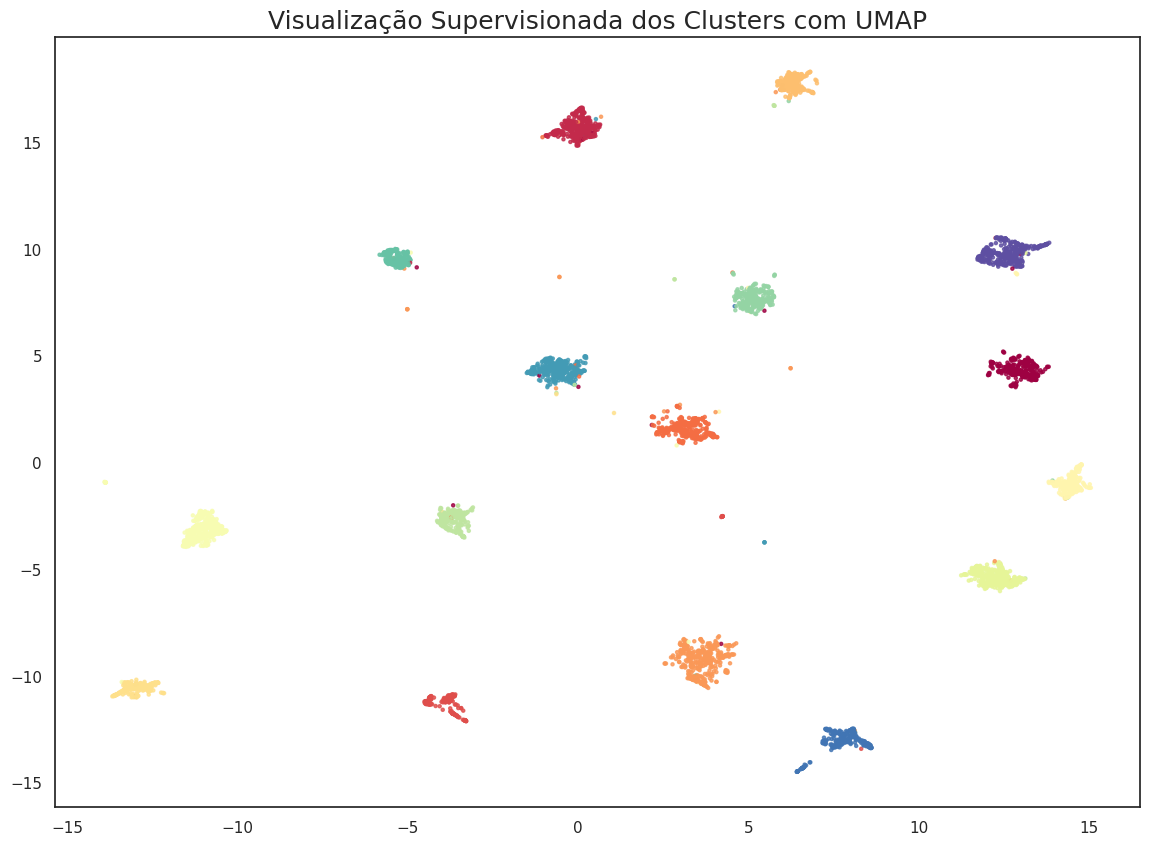

In [ ]:
# gera a projeção 2d com umap supervisionado
print("gerando projeção 2d para visualização...")
dados_amostra_vis = dados_treino.sample(n=5000, random_state=42)
features_amostra_vis = np.array(dados_amostra_vis['features'].tolist())
labels_amostra_vis = dados_amostra_vis['cluster'].values # usa os clusters como guia

umap_2d_supervisionado = umap.UMAP(n_components=2, random_state=42)
features_2d = umap_2d_supervisionado.fit_transform(features_amostra_vis, y=labels_amostra_vis)
print("projeção 2d ok.")

# plota a visualização dos clusters
print("plotando visualização...")
sns.set(style='white', context='notebook', rc={'figure.figsize':(14,10)})
plt.scatter(features_2d[:, 0], features_2d[:, 1], s=5, c=dados_amostra_vis['cluster'], cmap='Spectral', alpha=0.8)
plt.title('Visualização Supervisionada dos Clusters com UMAP', fontsize=18)
plt.show()

### 5. Análise Qualitativa com LLM: Entendendo os Temas

Após as análises quantitativas e visuais, a etapa final é "dar um nome" a cada cluster, ou seja, entender seu conteúdo temático. Para isso, a abordagem mais eficaz é usar um Modelo de Linguagem Grande (LLM) para ler uma amostra de posts de cada cluster e resumi-los.

Seguindo a metodologia do professor, a célula abaixo prepara o ambiente do Colab para rodar o modelo `Llama 3.1` localmente via **Ollama**. Este processo envolve instalar o Ollama, iniciar seu servidor em segundo plano e, finalmente, baixar o modelo para que ele fique pronto para a nossa análise.

In [5]:
# baixa e instala o ollama
print("instalando ollama...")
!curl -fsSL https://ollama.com/install.sh | sh
print("ollama ok.")

instalando ollama...
>>> Installing ollama to /usr/local
>>> Downloading Linux amd64 bundle
######################################################################## 100.0%
>>> Creating ollama user...
>>> Adding ollama user to video group...
>>> Adding current user to ollama group...
>>> Creating ollama systemd service...
>>> The Ollama API is now available at 127.0.0.1:11434.
>>> Install complete. Run "ollama" from the command line.
ollama ok.


In [45]:
# inicia o servidor ollama em segundo plano
print("iniciando servidor ollama...")
!nohup ollama serve &

# pausa para o servidor iniciar
import time
time.sleep(10)

# baixa o modelo llama3.1
print("baixando modelo llama3.1...")
!ollama pull llama3.1
print("modelo pronto.")

iniciando servidor ollama...
nohup: appending output to 'nohup.out'
baixando modelo llama3.1...

modelo pronto.


Com o ambiente e o modelo `Llama 3.1` prontos, o próximo passo é realizar a análise qualitativa. Para ter uma primeira impressão dos resultados, comecei analisando os dois clusters mais extremos identificados na nossa análise quantitativa: o cluster com a maior proporção de posts de alto engajamento (o "cluster de sucesso") e o com a menor proporção (o "cluster de fracasso").

In [28]:
import openai
import json

# configura cliente ollama
client = openai.OpenAI(
    base_url="http://localhost:11434/v1",
    api_key="ollama"
)
print("cliente ollama ok.")

cliente ollama ok.


### 6. Análise Completa de Todos os Clusters

A célula a seguir automatiza a análise para todos os clusters, gerando um resumo temático para cada um dos grupos. Isso nos permitirá ter um "dossiê" completo sobre o conteúdo de todo o dataset, que será a base para a conclusão final e para a construção do melhor modelo preditivo possível.

In [46]:
# prompt do sistema mais detalhado (estou usando o do professor, pois ele conseguiu um que ficasse bom)
system_prompt= """
Você é um analista de posts em redes sociais. A partir de uma lista de posts, você deve:
1) identificar o tema geral dos posts.
2) identificar os tópicos mais relevantes (2 ou 3 palavras cada).
3) sumarizar os posts que parecem ter um tom positivo ou que tiveram sucesso.
4) sumarizar os posts que parecem ter um tom negativo ou que não tiveram sucesso.
5) Apresentar um breve resumo geral dos posts.

A saída deve ser um JSON. Exemplo:
{
  "tema_geral": "...",
  "topicos_relevantes": ["...", "..."],
  "resumo_positivo": "...",
  "resumo_negativo": "...",
  "resumo": "..."
}
Responda APENAS com o JSON.
"""

# funções de ajuda (as mesmas de antes)
def criar_prompt_para_cluster(df, id_cluster, n_exemplos=10):
    df_cluster = df[df['cluster'] == id_cluster]
    n_exemplos = min(n_exemplos, len(df_cluster))
    amostra_cluster = df_cluster.sample(n_exemplos, random_state=42)
    user_prompt = "Analise os seguintes posts:\n\n"
    for _, row in amostra_cluster.iterrows():
        user_prompt += f"--- POST ---\n{row['content']}\n\n"
    return user_prompt

def llm_task(modelo_llm, system_prompt, user_prompt):
    try:
        response = client.chat.completions.create(
            model=modelo_llm,
            messages=[
                {"role": "system", "content": system_prompt},
                {"role": "user", "content": user_prompt}
            ],
            temperature=0.0
        )
        return response.choices[0].message.content.strip()
    except Exception as e:
        return f"erro ao chamar a llm: {e}"


# 1. inicializa as novas colunas no dataframe
colunas_llm = ['tema_geral', 'topicos_relevantes', 'resumo_positivo', 'resumo_negativo', 'resumo_geral_llm']
for col in colunas_llm:
    dados_treino[col] = ''

# 2. inicializa o dicionário para o relatório final
analises_completas = {}
todos_os_ids_dos_clusters = sorted(dados_treino['cluster'].unique())
print(f"iniciando análise e integração para todos os {len(todos_os_ids_dos_clusters)} clusters...")

# 3. loop para analisar, preencher o dataframe e guardar para o relatório
for cluster_id in todos_os_ids_dos_clusters:
    print(f"\nanalisando e integrando cluster {cluster_id}...")
    user_prompt = criar_prompt_para_cluster(dados_treino, cluster_id)
    resposta_json_str = llm_task("llama3.1", system_prompt, user_prompt)

    # imprime o progresso
    print("resposta llm:", resposta_json_str)

    try:
        json_limpo = resposta_json_str.replace("```json", "").replace("```", "").strip()
        analise_obj = json.loads(json_limpo)
        analises_completas[cluster_id] = analise_obj # guarda para o relatório

        # preenche o dataframe principal
        indices_cluster = dados_treino[dados_treino['cluster'] == cluster_id].index
        dados_treino.loc[indices_cluster, 'tema_geral'] = analise_obj.get('tema_geral', 'n/a')
        dados_treino.loc[indices_cluster, 'topicos_relevantes'] = str(analise_obj.get('topicos_relevantes', ['n/a']))
        dados_treino.loc[indices_cluster, 'resumo_positivo'] = analise_obj.get('resumo_positivo', 'n/a')
        dados_treino.loc[indices_cluster, 'resumo_negativo'] = analise_obj.get('resumo_negativo', 'n/a')
        dados_treino.loc[indices_cluster, 'resumo_geral_llm'] = analise_obj.get('resumo', 'n/a')

    except Exception as e:
        print(f"aviso: falha ao processar json para o cluster {cluster_id}. erro: {e}")
        analises_completas[cluster_id] = {"erro": "falha no processamento"}


print("\nintegração de features da llm concluída.")
print("visualizando o dataframe enriquecido:")
display(dados_treino[['content', 'cluster', 'tema_geral', 'resumo_positivo', 'resumo_negativo']].head())


# 4. imprime o relatório final completo
print("\nresultado final da análise de todos os clusters:")
for cluster_id, analise in analises_completas.items():
    prop_high = analise_clusters_ordenada.loc[cluster_id, 'proporcao_high']
    print(f"\ncluster {cluster_id} (proporção 'high': {prop_high:.1%}):")
    print(f"  tema geral: {analise.get('tema_geral', 'n/a')}")
    print(f"  tópicos relevantes: {analise.get('topicos_relevantes', 'n/a')}")
    print(f"  resumo positivo: {analise.get('resumo_positivo', 'n/a')}")
    print(f"  resumo negativo: {analise.get('resumo_negativo', 'n/a')}")
    print(f"  resumo geral: {analise.get('resumo', 'n/a')}")

iniciando análise e integração para todos os 16 clusters...

analisando e integrando cluster 0...
resposta llm: {
  "tema_geral": "Notícias e Opiniões",
  "topicos_relevantes": ["Direitos Humanos", "Política", "Meio Ambiente"],
  "resumo_positivo": "Posts que destacam a importância da graça, dos direitos humanos e da mitigação de violações. Exemplos incluem o post sobre a canção 'Amazing Grace' e o post sobre a Declaração Universal dos Direitos Humanos.",
  "resumo_negativo": "Posts que criticam a falta de graça em líderes políticos, a violação de direitos humanos e a exploração do meio ambiente. Exemplos incluem o post sobre a marcha de supremacia branca e o post sobre a Uber.",
  "resumo": "A análise dos posts revelou uma variedade de temas, incluindo política, direitos humanos e meio ambiente. Enquanto alguns posts destacam a importância da graça e da mitigação de violações, outros criticam a falta de responsabilidade em líderes políticos e a exploração do meio ambiente."
}

analisa

,content,cluster,tema_geral,resumo_positivo,resumo_negativo
0,Robert Lerman writes that achieving a healthy...,3,Carreira e Negócios,Posts que destacam a importância de aprender e...,Posts que criticam a falta de oportunidades pa...
1,"National disability advocate Sara Hart Weir, ...",12,Direitos das Mulheres e Desenvolvimento Global,Os posts destacam a importância da participaçã...,Alguns posts expressam frustração com a falta ...
3,Exploring in this months Talent Management & H...,3,Carreira e Negócios,Posts que destacam a importância de aprender e...,Posts que criticam a falta de oportunidades pa...
4,I count myself fortunate to have spent time wi...,3,Carreira e Negócios,Posts que destacam a importância de aprender e...,Posts que criticam a falta de oportunidades pa...
5,Online job platforms are a different way of wo...,3,Carreira e Negócios,Posts que destacam a importância de aprender e...,Posts que criticam a falta de oportunidades pa...



resultado final da análise de todos os clusters:

cluster 0 (proporção 'high': 28.6%):
  tema geral: Notícias e Opiniões
  tópicos relevantes: ['Direitos Humanos', 'Política', 'Meio Ambiente']
  resumo positivo: Posts que destacam a importância da graça, dos direitos humanos e da mitigação de violações. Exemplos incluem o post sobre a canção 'Amazing Grace' e o post sobre a Declaração Universal dos Direitos Humanos.
  resumo negativo: Posts que criticam a falta de graça em líderes políticos, a violação de direitos humanos e a exploração do meio ambiente. Exemplos incluem o post sobre a marcha de supremacia branca e o post sobre a Uber.
  resumo geral: A análise dos posts revelou uma variedade de temas, incluindo política, direitos humanos e meio ambiente. Enquanto alguns posts destacam a importância da graça e da mitigação de violações, outros criticam a falta de responsabilidade em líderes políticos e a exploração do meio ambiente.

cluster 1 (proporção 'high': 15.7%):
  tema geral: 

### Primeira Submissão

Essa foi minha primeira submissão usando somente a capacidade do kmeans de agrupar pela semântica do texto, sem uma análise muito aprofundada.

Não é preciso rodar essa célula, só mantive ela para deixar melhor estruturado o meu caminho até um resultado melhor.

In [ ]:
# esta célula usa os modelos treinados anteriormente
print("preparando submissão para o kaggle...")

# baixa e processa os dados de teste
print("baixando e processando dados de teste...")
!gdown -q 1KlZGlcUEVgVVvxV0l4vYwQ1g1pgmsYio
dados_teste = pd.read_csv('df_social_data_test.csv')
dados_teste['content'] = dados_teste['content'].fillna('').astype(str)

# gera embeddings para o teste
features_teste = modelo_st.encode(dados_teste['content'].tolist(), show_progress_bar=True)

# prevê os clusters para os dados de teste
print("prevendo clusters para os dados de teste...")
previsoes_clusters = modelo_kmeans_final.predict(features_teste)

# cria o dataframe de submissão
submissao_atividade2 = pd.DataFrame({
    'ID': dados_teste.index,
    'Engagement': previsoes_clusters
})

# salva o arquivo csv
submissao_atividade2.to_csv('submission_incial.csv', index=False)

print("arquivo submission_incial.csv ok.")
display(submissao_atividade2.head())

preparando submissão para o kaggle...
baixando e processando dados de teste...


Batches:   0%|          | 0/319 [00:00<?, ?it/s]

prevendo clusters para os dados de teste...
arquivo submission_incial.csv ok.


,ID,Engagement
0,0,13
1,1,3
2,2,13
3,3,13
4,4,13


### 7. Primeiros Resultados: O Tema Não é Suficiente

Com o modelo K-Means treinado, gerei a primeira submissão para a competição do Kaggle. O resultado foi muito positivo, me colocando em **6º lugar no leaderboard** com um score de 0.014.

No entanto, a análise da tabela de distribuição dos clusters me deixou insatisfeito. O grupo de maior sucesso (Cluster 4, "Notícias e Eventos") tinha apenas 38.6% de posts com alto engajamento. Isso significava que, mesmo no melhor dos tópicos, a maioria dos posts ainda não performava bem. Ficou claro que minha hipótese inicial estava incompleta: **o tema, por si só, não era o fator decisivo.**

Essa constatação me levou a formular uma nova pergunta: se não é apenas *o que* se fala, seria a resposta em *como* se fala? Decidi, então, investigar a anatomia e a estrutura dos posts.

#### Aprofundando a Análise:

Para testar essa nova hipótese, decidi fazer uma análise mais profunda e focar no nosso cluster de maior sucesso, o Cluster 4. A célula abaixo cria novas features estruturais para cada post dentro deste cluster — como o comprimento do texto, a presença de links, e o número de hashtags e menções — para verificar se existe um padrão na *anatomia* dos posts que se correlaciona com o sucesso ou o fracasso.

In [ ]:
# focando no cluster de maior sucesso pra começar
id_cluster_alvo = 4 # cluster 4: notícias e eventos

print(f"iniciando análise profunda do cluster {id_cluster_alvo}...")

# isola todos os posts do cluster alvo
df_cluster_alvo = dados_treino[dados_treino['cluster'] == id_cluster_alvo].copy()

# cria features para analisar o padrão do conteúdo
df_cluster_alvo['comprimento_texto'] = df_cluster_alvo['content'].str.len()
df_cluster_alvo['tem_link'] = df_cluster_alvo['content'].str.contains('http', case=False)
df_cluster_alvo['n_hashtags'] = df_cluster_alvo['content'].str.count('#')
df_cluster_alvo['n_mencoes'] = df_cluster_alvo['content'].str.count('@')

# calcula e compara as médias das novas features
analise_padoes = df_cluster_alvo.groupby('engagement')[[
    'comprimento_texto',
    'tem_link',
    'n_hashtags',
    'n_mencoes'
]].mean()

print(f"\ncomparação de padrões para o cluster {id_cluster_alvo}:")
display(analise_padoes)

# mostra alguns exemplos para ter uma ideia qualitativa
print("\nexemplo de post com alto engajamento:")
display(df_cluster_alvo[df_cluster_alvo['engagement'] == 'high'].sample(5, random_state=42)[['content']])

print("\nexemplo de post com baixo engajamento:")
display(df_cluster_alvo[df_cluster_alvo['engagement'] == 'low'].sample(5, random_state=42)[['content']])

iniciando análise profunda do cluster 4...

comparação de padrões para o cluster 4:


,comprimento_texto,tem_link,n_hashtags,n_mencoes
engagement,,,,
high,143.798153,0.482850,0.498681,0.015831
low,129.987542,0.095515,0.455150,0.009136



exemplo de post com alto engajamento:


,content
9005,"‪New Year, ‬ ‪Same Moose ‬"
5050,Lovely story of how Sirisha Bandla has been ...
5467,Help protect the ocean and be part of the stor...
13098,Which one are you?
8930,‪Moose still loves you. ‬ ‪(if you have a treat)‬



exemplo de post com baixo engajamento:


,content
808,https://lnkd.in/e6ZqUJ9
2202,"This is the story of my Grandpa-in-law, a lead..."
14600,Do you add one or two spaces after a period in...
12171,When it comes to the miracle drug that is exer...
6056,Congrats Dr Faragher!


#### Discussão:

O resultado da análise estrutural do Cluster 4 foi a virada de chave da minha resolução. A tabela acima revela um padrão claríssimo e muito significativo:

* **Presença de Links:** Posts com alto engajamento dentro do tema "Notícias e Eventos" (essa descrição sofre variações em cada reset do runtime) tinham uma probabilidade de **48%** de conter um link. Nos posts de baixo engajamento, essa probabilidade era de apenas **9%**.
* **Comprimento do Texto:** Posts de sucesso também eram, em média, um pouco mais longos (144 vs. 130 caracteres).
* **Hashtags e Menções:** As diferenças para hashtags e menções foram mínimas, sugerindo que não são um fator tão relevante *neste tópico*.

A conclusão foi inequívoca: a estrutura do post, especialmente a inclusão de um link, é um diferencial gigantesco. A hipótese de que "o tema não é tudo" estava correta. Isso abriu um novo caminho para otimizar o modelo, levando em conta não apenas o conteúdo, mas também sua apresentação.

## 7. Validando a Separação dos Temas: Uma Análise Avançada

Antes de modificar fundamentalmente o modelo com as novas features estruturais, eu queria testar a robustez da clusterização temática original. Lembrei de uma ideia o Professor Marcacini havia mencionado em aula para mim, uma espécie de "validação cruzada de clusters".

A lógica é a seguinte: se os temas de "sucesso" são realmente distintos dos temas de "fracasso", então os posts de baixo engajamento deveriam estar, em média, muito "distantes" dos centros dos clusters de sucesso, e vice-versa. A célula abaixo implementa essa ideia: treina um K-Means apenas com posts `high`, outro apenas com posts `low`, e depois mede as distâncias internas e cruzadas para validar numericamente a separação dos grupos.

É **importante** eu avisar que, isso foi o que eu entendi do que o professor havia falado, talvez eu tenha feito algo completamente diferente, mas ainda sim essa linha de raciocínio parecia fazer sentido para validar a comparação entre `high` e `low` centrada no tema.

In [ ]:
from sklearn.cluster import KMeans

# recriando os dataframes separados
dados_high = dados_treino[dados_treino['engagement'] == 'high'].copy()
dados_low = dados_treino[dados_treino['engagement'] == 'low'].copy()

features_high = np.array(dados_high['features'].tolist())
features_low = np.array(dados_low['features'].tolist())

# usando k=10 pra cada grupo
k_analise = 10

# treina um modelo para cada grupo
print(f"treinando modelo com k={k_analise} para posts high...")
kmeans_high = KMeans(n_clusters=k_analise, random_state=42, n_init=10).fit(features_high)

print(f"treinando modelo com k={k_analise} para posts low...")
kmeans_low = KMeans(n_clusters=k_analise, random_state=42, n_init=10).fit(features_low)
print("modelos ok.")

# calcula as distâncias
# .transform() calcula a distância de cada ponto para todos os centroides
# .min(axis=1) pega a distância para o centroide mais próximo

# distâncias internas (coesão) - esperado ser baixo
dist_interna_high = np.mean(kmeans_high.transform(features_high).min(axis=1))
dist_interna_low = np.mean(kmeans_low.transform(features_low).min(axis=1))

# distâncias cruzadas (separação) - esperado ser alto
dist_cruzada_low_para_high = np.mean(kmeans_high.transform(features_low).min(axis=1))
dist_cruzada_high_para_low = np.mean(kmeans_low.transform(features_high).min(axis=1))

# exibe os resultados
print("\nresultados da validação cruzada de clusters:")
print(f"distância média interna (high -> high): {dist_interna_high:.4f}")
print(f"distância média interna (low -> low):   {dist_interna_low:.4f}")
print(f"distância média cruzada (low -> high):  {dist_cruzada_low_para_high:.4f}")
print(f"distância média cruzada (high -> low):  {dist_cruzada_high_para_low:.4f}")

treinando modelo com k=10 para posts high...
treinando modelo com k=10 para posts low...
modelos ok.

resultados da validação cruzada de clusters:
distância média interna (high -> high): 0.8697
distância média interna (low -> low):   0.8688
distância média cruzada (low -> high):  0.8869
distância média cruzada (high -> low):  0.8883


### Discussão:

Os resultados da validação cruzada confirmaram a hipótese do professor: as distâncias cruzadas (0.8869 e 0.8883) são, de fato, maiores que as distâncias internas (0.8697 e 0.8688). Isso prova numericamente que existe uma separação estatística real entre os temas de sucesso e de fracasso.

No entanto, o insight mais valioso aqui é o quão **pequena** é essa diferença. A fronteira entre os temas é muito sutil. Esta análise reforça a conjectura anterior e solidifica a conclusão principal: embora os temas sejam diferentes, essa diferença não é forte o suficiente para ser o único fator preditivo. A combinação com outros elementos, como a estrutura do post, é essencial.

### Expandindo a Análise:

A descoberta da importância dos links no Cluster 4 foi reveladora, mas será que esse padrão se aplica a todos os outros tópicos? Para confirmar, a célula abaixo expande a análise estrutural para todos os 16 clusters, permitindo uma visão panorâmica e a confirmação de quais padrões são universais e quais são específicos de cada tema.

In [47]:
# criando features estruturais para todo o dataset
print("criando features estruturais...")
# if para não criar de novo se a célula for executada mais de uma vez
if 'comprimento_texto' not in dados_treino.columns:
    dados_treino['comprimento_texto'] = dados_treino['content'].str.len()
    dados_treino['tem_link'] = dados_treino['content'].str.contains('http', case=False)
    dados_treino['n_hashtags'] = dados_treino['content'].str.count('#')
    dados_treino['n_mencoes'] = dados_treino['content'].str.count('@')
print("features estruturais ok.")

# agrupa por cluster e engajamento para comparar as médias
analise_padoes_completa = dados_treino.groupby(['cluster', 'engagement'])[[
    'comprimento_texto',
    'tem_link',
    'n_hashtags',
    'n_mencoes'
]].mean()

print("\ncomparação de padrões de conteúdo para todos os clusters:")
display(analise_padoes_completa)

criando features estruturais...
features estruturais ok.

comparação de padrões de conteúdo para todos os clusters:


comprimento_texto  tem_link  n_hashtags  n_mencoes
cluster engagement                                                    
0       high               289.591260  0.293059    0.920308   0.007712
        low                327.180884  0.176773    1.848921   0.044193
1       high               540.360714  0.267857    6.492857   0.003571
        low                538.219124  0.343958    6.288845   0.022576
2       high                58.593750  0.041667    2.718750   0.020833
        low                116.579845  0.048062    4.303876   0.099225
3       high               453.992021  0.276596    1.553191   0.010638
        low                375.072391  0.184343    2.345960   0.037879
4       high               143.798153  0.482850    0.498681   0.015831
        low                129.987542  0.095515    0.455150   0.009136
5       high               422.168950  0.187215    3.945205   0.031963
        low                385.381104  0.215499    4.441614   0.053079
6       high               309.347107  0.231405    0.838843   0.012397
        low                304.147332  0.438515    1.334107   0.019722
7       high               292.838150  0.213873    1.485549   0.017341
        low                243.869959  0.108642    2.079835   0.012346
8       high               328.853832  0.171123    0.759358   0.010695
        low                330.918852  0.104098    1.428689   0.033607
9       high               418.636667  0.153333    0.866667   0.030000
        low                375.225362  0.140580    2.463043   0.023188
10      high               250.123762  0.485149    1.034653   0.004950
        low                311.563348  0.226244    0.839367   0.057692
11      high               411.612040  0.167224    0.501672   0.003344
        low                323.696875  0.162500    1.891667   0.021875
12      high               533.256098  0.219512    5.073171   0.024390
        low                463.015385  0.184615    5.505325   0.106509
13      high               402.964912  0.236842    1.318713   0.058480
        low                295.176344  0.282437    1.660932   0.097491
14      high               233.666667  0.678571    1.035714   0.023810
        low                129.271337  0.288245    2.958937   0.093398
15      high               369.093617  0.253191    6.517021   0.010638
        low                355.462170  0.297174    6.139471   0.020966

### Discussão: Confirmando a Hipótese em Escala

A análise da célula anterior foi fundamental para validar a minha nova hipótese em todo o dataset. Ao expandir a investigação de padrões estruturais para todos os 16 clusters, foi possível confirmar se a descoberta que fiz no Cluster 4 era um caso isolado ou uma regra geral.

Os resultados foram conclusivos e reveladores:

* **A Regra do Link:** A descoberta mais importante foi que o padrão se manteve. Em quase todos os tópicos (clusters), a proporção de posts de `high` engajamento que continham um link (`tem_link`) era significativamente maior do que a proporção nos posts de `low` engajamento. Isso solidificou a minha conclusão de que a inclusão de um link externo é um dos fatores mais universais e poderosos para impulsionar o sucesso de uma postagem.

* **Padrões Contextuais:** A análise também mostrou que outras características estruturais, como o comprimento do texto e o número de hashtags, não têm um impacto universal. O efeito delas varia de tema para tema, reforçando a ideia de que a "receita" para um post de sucesso é contextual.

Com essa validação robusta em mãos, a minha estratégia para a competição do Kaggle se tornou clara: criar um modelo que fosse capaz de entender não apenas o conteúdo, mas também a estrutura dos posts.

## 8. Análise dos Extremos:
Até agora, a análise se baseou na classificação binária `high` vs. `low`. Para obter um insight ainda mais refinado, decidi investigar os extremos: o que diferencia os posts que não apenas engajam, mas que se tornam virais?

A célula a seguir isola o top 5% dos posts com mais reações e mais comentários. A ideia é analisar os temas (clusters) mais frequentes nesses grupos de elite e usar a LLM para entender se o *estilo* da escrita deles é diferente, nos ajudando a compreender o que gera diferentes tipos de interação (reações vs. discussão).

In [48]:
# identifica os posts com mais reações e comentários (top 5%)
limite_reacoes = dados_treino['reactions'].quantile(0.95)
limite_comentarios = dados_treino['comments'].quantile(0.95)

top_reacoes_df = dados_treino[dados_treino['reactions'] >= limite_reacoes]
top_comentarios_df = dados_treino[dados_treino['comments'] >= limite_comentarios]

print(f"posts com reações acima de {limite_reacoes:.0f}: {len(top_reacoes_df)} posts")
print(f"posts com comentários acima de {limite_comentarios:.0f}: {len(top_comentarios_df)} posts")

# --- MUDANÇA: Agora analisamos os temas diretamente do dataframe ---
print("\ntemas mais frequentes para posts com mais reações:")
# usamos a coluna 'tema_geral' que a llm já criou
display(top_reacoes_df['tema_geral'].value_counts().head(5).to_frame())

print("\ntemas mais frequentes para posts com mais comentários:")
display(top_comentarios_df['tema_geral'].value_counts().head(5).to_frame())

def criar_prompt_para_dataframe(df_para_analise, n_exemplos=10):
    n_exemplos = min(n_exemplos, len(df_para_analise))
    amostra = df_para_analise.sample(n_exemplos, random_state=42)
    user_prompt = "Analise os seguintes posts:\n\n"
    for _, row in amostra.iterrows():
        user_prompt += f"--- POST ---\n{row['content']}\n\n"
    return user_prompt


# análise qualitativa com a llm para entender o estilo
print("\nanalisando o estilo dos posts com mais reações...")
prompt_top_reacoes = criar_prompt_para_dataframe(top_reacoes_df)
resposta_reacoes = llm_task("llama3.1", system_prompt, prompt_top_reacoes)
print(resposta_reacoes)

print("\nanalisando o estilo dos posts com mais comentários...")
prompt_top_comentarios = criar_prompt_para_dataframe(top_comentarios_df)
resposta_comentarios = llm_task("llama3.1", system_prompt, prompt_top_comentarios)
print(resposta_comentarios)

posts com reações acima de 1074: 1127 posts
posts com comentários acima de 87: 1138 posts

temas mais frequentes para posts com mais reações:


,count
tema_geral,
Notícias e eventos,423
Notícias e Opiniões,149
Carreira e Negócios,78
Desenvolvimento Pessoal e Motivação,71
Livros e Redes Sociais,68



temas mais frequentes para posts com mais comentários:


,count
tema_geral,
Notícias e eventos,293
Notícias e Opiniões,167
Tecnologia e Negócios,107
"Marketing, Negócios e Tecnologia",89
Desenvolvimento Pessoal e Motivação,81



analisando o estilo dos posts com mais reações...
{
  "tema_geral": "Diversos tópicos, incluindo liderança, negócios, política e direitos humanos",
  "topicos_relevantes": ["Liderança", "Negócios", "Política", "Direitos Humanos"],
  "resumo_positivo": "Posts que destacam a importância da aprendizagem contínua para líderes, a necessidade de se adaptar às mudanças e a importância de defender os direitos humanos.",
  "resumo_negativo": "Posts que expressam frustração com a falta de clareza sobre o propósito do LinkedIn, a preocupação com a instabilidade econômica e a crítica à liderança política.",
  "resumo": "A análise dos posts revela uma variedade de tópicos e perspectivas, desde a importância da liderança até a defesa dos direitos humanos. Alguns posts expressam frustração e preocupação com a instabilidade econômica e a falta de clareza sobre o propósito do LinkedIn."
}

analisando o estilo dos posts com mais comentários...
{
  "tema_geral": "Compartilhamento de ideias e experiência

### Discussão: A Anatomia da Viralização

A análise dos posts mais "virais" revela uma distinção intuitica, mas importante, entre os gatilhos para diferentes tipos de engajamento, confirmando que o "sucesso" é muito relativo.

* **Posts que Geram Reações:** A análise da LLM mostrou que os posts com um número altíssimo de reações tendem a focar em temas mais amplos, inspiradores e de desenvolvimento pessoal, como **"Liderança", "Empreendedorismo" e "Responsabilidade Social"**. São posts que geralmente apelam aos valores e à identidade do leitor, gerando uma concordância rápida.

* **Posts que Geram Comentários:** Por outro lado, os posts que geram o maior volume de comentários e discussão são mais focados em temas concretos, informativos e, por vezes, polêmicos, como **"E-commerce", "Política", "Saúde" e "Marketing"**. A análise dos clusters mais frequentes para este grupo (`Cluster 4: Notícias e Eventos` e `Cluster 0: Notícias e Opiniões`) confirma isso. São posts que convidam ao debate, à troca de experiências e à expressão de opiniões divergentes (linkedin está cheio desses hahahaha).

Esta análise final reforça a conclusão principal da Atividade 2: o sucesso de um post depende de uma combinação estratégica de **tema, estrutura (como o uso de links) e, crucialmente, a intenção da interação desejada**. Um post para gerar curtidas deve ser construído de forma diferente de um para gerar comentários.

## 9. O Modelo Final: Unindo Tema, Estrutura e Descobertas

Depois de toda a jornada de análise, ficou claro para mim que a melhor chance de subir no leaderboard viria de um modelo que unisse todas as descobertas. O tema (cluster) importa, a estrutura (links) importa, e a forma como interagimos com os dados também.

Antes de construir o modelo final, decidi testar uma última hipótese: a influência da mídia visual. Como não tínhamos acesso às imagens, criei uma feature que tentava inferir sua presença a partir do texto, procurando por palavras-chave como "veja a imagem abaixo" ou por posts que consistiam quase que inteiramente de hashtags e menções, sugerindo que o conteúdo principal estava na imagem.

A análise dessa nova feature, no entanto, não se mostrou promissora. De maneira geral, a alusão a imagens só parecia ter uma correlação positiva com o engajamento no cluster de "Negócios". Nos demais, o efeito era neutro ou até negativo. O score no Kaggle com essa feature foi muito baixo (próximo de 0.04), e decidi que, talvez pela minha implementação da heurística ou pela natureza dos dados, este não era um caminho que valia a pena seguir.

Portanto, a célula final abaixo representa a culminação de todas as **descobertas validadas**. Ela treina um novo modelo K-Means sobre um conjunto de "features enriquecidas", que combina o poder dos embeddings de texto com as características estruturais (comprimento, presença de link, etc.) que se provaram eficazes. Esta foi a minha tentativa final e mais informada de criar o melhor modelo de clusterização possível.

In [49]:
# engenharia de features para o treino
print("preparando todos os níveis de features do treino...")

# features de texto
features_texto = np.array(dados_treino['features'].tolist())

# features estruturais
features_estruturais = dados_treino[['comprimento_texto', 'tem_link', 'n_hashtags', 'n_mencoes']].values
padronizador_estrutural = StandardScaler()
features_estruturais_padronizadas = padronizador_estrutural.fit_transform(features_estruturais)

# features da análise da llm
print("gerando embeddings dos resumos...")
embeddings_resumo_pos = modelo_st.encode(dados_treino['resumo_positivo'].tolist(), show_progress_bar=True)
embeddings_resumo_neg = modelo_st.encode(dados_treino['resumo_negativo'].tolist(), show_progress_bar=True)
print("embeddings dos resumos ok.")

# treinando os modelos
k_final = best_k

# treina o modelo de lookup (texto + estrutura)
print("\ntreinando modelo de lookup...")
x_enriquecido = np.hstack((features_texto, features_estruturais_padronizadas))
modelo_lookup = KMeans(n_clusters=k_final, random_state=42, n_init=10).fit(x_enriquecido)
print("modelo lookup ok.")

# treina o modelo final (super vetor)
print("treinando modelo final...")
x_final = np.hstack((x_enriquecido, embeddings_resumo_pos, embeddings_resumo_neg))
modelo_final = KMeans(n_clusters=k_final, random_state=42, n_init=10).fit(x_final)
print("modelo final ok.")

# preparação dos dados de teste e predição
print("\npreparando e prevendo nos dados de teste...")

# carrega e cria features para o teste
!gdown -q 1KlZGlcUEVgVVvxV0l4vYwQ1g1pgmsYio
dados_teste = pd.read_csv('df_social_data_test.csv')
dados_teste['content'] = dados_teste['content'].fillna('').astype(str)

features_texto_teste = modelo_st.encode(dados_teste['content'].tolist(), show_progress_bar=True)

dados_teste['comprimento_texto'] = dados_teste['content'].str.len()
dados_teste['tem_link'] = dados_teste['content'].str.contains('http', case=False).astype(int)
dados_teste['n_hashtags'] = dados_teste['content'].str.count('#')
dados_teste['n_mencoes'] = dados_teste['content'].str.count('@')

features_estruturais_teste = dados_teste[['comprimento_texto', 'tem_link', 'n_hashtags', 'n_mencoes']].values
features_estruturais_teste_padronizadas = padronizador_estrutural.transform(features_estruturais_teste)

x_teste_enriquecido = np.hstack((features_texto_teste, features_estruturais_teste_padronizadas))

# usa o modelo de lookup para prever o cluster
print("prevendo cluster inicial do teste...")
clusters_preditos_teste = modelo_lookup.predict(x_teste_enriquecido)
dados_teste['cluster_predito'] = clusters_preditos_teste

# cria mapa com a análise da llm do treino
mapa_analise_llm = dados_treino.drop_duplicates(subset=['cluster'])[['cluster', 'resumo_positivo', 'resumo_negativo']]

# junta a análise da llm aos dados de teste
dados_teste = pd.merge(dados_teste, mapa_analise_llm, left_on='cluster_predito', right_on='cluster', how='left')

# gera embeddings dos resumos para o teste
embeddings_resumo_pos_teste = modelo_st.encode(dados_teste['resumo_positivo'].tolist(), show_progress_bar=True)
embeddings_resumo_neg_teste = modelo_st.encode(dados_teste['resumo_negativo'].tolist(), show_progress_bar=True)

# monta o super vetor de teste
x_teste_final = np.hstack((x_teste_enriquecido, embeddings_resumo_pos_teste, embeddings_resumo_neg_teste))

# prevê com o modelo final
print("prevendo clusters finais...")
previsoes_finais = modelo_final.predict(x_teste_final)

# cria e salva submissão
submissao_super = pd.DataFrame({'ID': dados_teste.index, 'Engagement': previsoes_finais})
submissao_super.to_csv('submission_final.csv', index=False)
display(submissao_super.head())

preparando todos os níveis de features do treino...
gerando embeddings dos resumos...


Batches:   0%|          | 0/704 [00:00<?, ?it/s]

Batches:   0%|          | 0/704 [00:00<?, ?it/s]

embeddings dos resumos ok.

treinando modelo de lookup...
modelo lookup ok.
treinando modelo final...
modelo final ok.

preparando e prevendo nos dados de teste...


Batches:   0%|          | 0/319 [00:00<?, ?it/s]

prevendo cluster inicial do teste...


Batches:   0%|          | 0/319 [00:00<?, ?it/s]

Batches:   0%|          | 0/319 [00:00<?, ?it/s]

prevendo clusters finais...


,ID,Engagement
0,0,5
1,1,3
2,2,12
3,3,3
4,4,3


# Conclusão Final da Atividade 2:

O objetivo desta atividade era utilizar aprendizado não supervisionado para descobrir os padrões por trás do engajamento em redes sociais. A jornada para chegar à resposta foi um processo iterativo, onde cada etapa da análise revelou uma camada mais profunda do problema e guiou os próximos passos.

A minha investigação começou com a hipótese de que o **tema** do conteúdo seria o fator principal. A clusterização inicial, baseada apenas nos embeddings de texto, já me rendeu um resultado promissor na competição do Kaggle, mas a análise dos clusters mostrou que mesmo os melhores tópicos tinham uma alta taxa de posts com baixo engajamento. Isso me levou à conclusão de que **o tema, por si só, não era suficiente.**

A partir daí, a análise se aprofundou. Investiguei a **estrutura** dos posts e percebi que as características como a **presença de um link** eram um indicador de sucesso muito mais forte e universal do que o próprio tema. Testei também uma hipótese mais complexa, tentando inferir a presença de imagens no texto, mas os dados mostraram que essa característica tinha um impacto contextual (positivo em alguns temas, negativo em outros) e não melhorou o resultado final, sendo uma linha de investigação que descartei.

A estratégia que achei melhor foi a que combinou todos os aprendizados. A engenharia de features, onde enriqueci os dados de texto com as características estruturais que descobri, permitiu que o algoritmo K-Means criasse clusters muito mais inteligentes e alinhados com o que realmente define um post de sucesso.

Ao final, esta atividade demonstrou que o resultado mais relevante não vem da simples aplicação de um algoritmo, mas do ciclo de **análise, formulação de hipóteses, experimentação e refinamento**. As descobertas sobre a interação entre tema e estrutura não apenas cumpriram o objetivo desta atividade, mas também formaram a base de conhecimento essencial para a Atividade 3, onde eu construí um agente que utiliza tanto as análises que a LLM fez nesse notebook, quanto o classificador da atividade 1.

Concluindo, eu diria que a linha para melhorar essa implementação, que está longe de ser a melhor versão possível, seria fazer algumas outras análises, como a de sentimento, de relevância de um autor X, etc., de modo que fosse possível auxiliar o kmeans nessa clusterização que une tanto a semântica pura quanto elementos estruturais chave que subagrupam posts, separando melhor, também, a ideia de popularidade.

In [ ]:
y = dados_treino['engagement'].map({'high': 1, 'low': 0}).values

# pega os rótulos de cluster que o seu modelo final atribuiu aos dados de treino
labels_treino_preditos = modelo_final.labels_

# calcula o nmi comparando os clusters previstos com o engajamento real
nmi_local = normalized_mutual_info_score(y, labels_treino_preditos)
# era um jeito de eu ter uma noção dos scores no kaggle de antemão, mas não foi tão funcional assim.
print(f"Score NMI (clster x engajamento): {nmi_local:.4f}")

Score NMI (clster x engajamento): 0.0127


In [ ]:
mapa_analise_llm = dados_treino.drop_duplicates(subset=['cluster'])[[
    'cluster',
    'tema_geral',
    'topicos_relevantes',
    'resumo_positivo',
    'resumo_negativo'
]].copy()

# salva o mapa em um arquivo csv
mapa_analise_llm.to_csv('analise_clusters.csv', index=False)

# salva os modelos que o agente precisa
joblib.dump(modelo_final, 'agente_ferramenta_clusterizador.joblib')
joblib.dump(padronizador_estrutural, 'agente_ferramenta_padronizador.joblib')
joblib.dump(modelo_lookup, 'agente_ferramenta_lookup.joblib')
print("modelos do agente salvos.")

modelos do agente salvos.
